# Task 1 – Supervised Learning

This notebook constitutes the core section of the supervised learning report for Task 1. The objective of the task is to perform five-class species recognition on the `dungeon_images_colour80` image dataset, with categories including `halfling`, `human`, `lizard`, `orc`, and `wingedrat`. We frame this problem as a single-label multi-classification task and compare two supervised learning methods: `HOG + Linear SVM` and `ResNet18 transfer learning`. 

The reason for choosing supervised learning is that there are already clear labels here. The goal is not to discover unlabeled structures, but to learn a classifier that can generalize stably to unseen images. This task is also very important in the course context: it directly corresponds to the "recognition" stage in the visual perception module. The model output will affect subsequent decisions, so fair comparison, feasible experiments, and clear error analysis are required. 

The external methods used in the text are referenced by numbers. The classic combination of HOG features and linear classifiers can be found in [1], and the residual learning idea of ResNet can be found in [2].

## Algorithm Choice and Rationale

**Method A: HOG + LinearSVM**

This is a traditional but very suitable course baseline. HOG encodes local edge orientation information into a fixed-length feature vector, and a linear margin classifier then performs the multi-class prediction. Its strengths are speed, clarity, and interpretability, and it often works well when the sample size is moderate and the class boundaries depend mainly on shape and local contours. For this dataset, the image size is fixed and the number of classes is small, so compressing the images with HOG and then feeding them into a linear SVM is a clean and strong baseline [1].

**Method B: ResNet18 transfer learning**

ResNet18 represents the deep transfer-learning route. It uses hierarchical visual representations learned on large-scale data, then replaces the classification head and fine-tunes the model for the current task. Compared with hand-crafted features, ResNet18 is much better at learning compositional patterns directly from raw pixels, which makes it a strong fit for this image classification problem. Because the class differences here involve both texture and shape, a residual network usually has more expressive power than hand-crafted features; using class weighting and early stopping also helps balance minority-class performance and overall generalization [2].

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image



def display(obj):
    if isinstance(obj, pd.DataFrame):
        print(obj.to_string())
    elif isinstance(obj, pd.Series):
        print(obj.to_string())
    else:
        print(obj)
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'task1_supervised' / 'src' / 'common.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the AIR repository root.')


PROJECT_ROOT = find_project_root()
TASK1_ROOT = PROJECT_ROOT / 'task1_supervised'
SRC_DIR = TASK1_ROOT / 'src'
CONFIGS_DIR = TASK1_ROOT / 'configs'
OUTPUTS_DIR = TASK1_ROOT / 'outputs'
DATA_DIR = PROJECT_ROOT / 'dungeon_images_colour80'

sys.path.insert(0, str(SRC_DIR))

from common import CLASS_ORDER, build_classification_outputs, ensure_dirs, get_class_names, set_global_seed

set_global_seed(42)
ensure_dirs(OUTPUTS_DIR / 'figures', OUTPUTS_DIR / 'tables')

print(f'Project root: {PROJECT_ROOT}')
print(f'Task1 root:   {TASK1_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Src dir:      {SRC_DIR}')

Project root: /Users/ziyanlei/Desktop/AIR
Task1 root:   /Users/ziyanlei/Desktop/AIR/task1_supervised
Data dir:     /Users/ziyanlei/Desktop/AIR/dungeon_images_colour80
Src dir:      /Users/ziyanlei/Desktop/AIR/task1_supervised/src


## Environment Setup and Import

We first load the configuration files and check whether the split satisfies the group-leakage constraint. The split manifest is generated by `src/build_split_manifest.py`, which tries to keep samples from the same prefix/bucket in the same split so that training, validation, and test leakage is minimized.

In [2]:
def load_json(path: Path) -> Dict[str, Any]:
    return json.loads(path.read_text(encoding='utf-8'))


hog_cfg = load_json(CONFIGS_DIR / 'hog_svm.json')
resnet_cfg = load_json(CONFIGS_DIR / 'resnet18.json')
config_df = pd.DataFrame(
    [
        {'method': 'hog_svm', **hog_cfg},
        {'method': 'resnet18', **resnet_cfg},
    ]
)

print('Key configuration parameters:')
display(config_df)

Key configuration parameters:
     method  seed  image_size         c_values                                                        notes  epochs  warmup_epochs  batch_size  learning_rate_head  learning_rate_full  weight_decay  patience
0   hog_svm    42        80.0  [0.1, 1.0, 3.0]  Method A baseline with balanced linear SVM on HOG features.     NaN            NaN         NaN                 NaN                 NaN           NaN       NaN
1  resnet18    42         NaN              NaN  Method B baseline transfer learning with class-weighted CE.     8.0            2.0        64.0               0.001              0.0001        0.0001       3.0


In [3]:
manifest = pd.read_csv(OUTPUTS_DIR / 'tables' / 'split_manifest.csv')
split_stats = pd.read_csv(OUTPUTS_DIR / 'tables' / 'split_stats.csv')

assert manifest['image_path'].map(lambda p: Path(p).exists()).all(), 'Some image files referenced in the manifest are missing.'
assert manifest.groupby('group_id')['split'].nunique().max() == 1, 'Group leakage detected across splits.'

class_names = get_class_names(manifest['label'].tolist())
pivot_stats = (
    split_stats.pivot(index='label', columns='split', values='count')
    .reindex(index=class_names)
    .fillna(0)
    .astype(int)
)

print(f'Manifest rows: {len(manifest):,}')
print(f'Classes: {class_names}')
display(pivot_stats)

Manifest rows: 8,018
Classes: ['halfling', 'human', 'lizard', 'orc', 'wingedrat']
split      test  train  val
label                      
halfling    200    928  198
human       483   2254  483
lizard      225   1051  228
orc         207    968  208
wingedrat    92    407   86


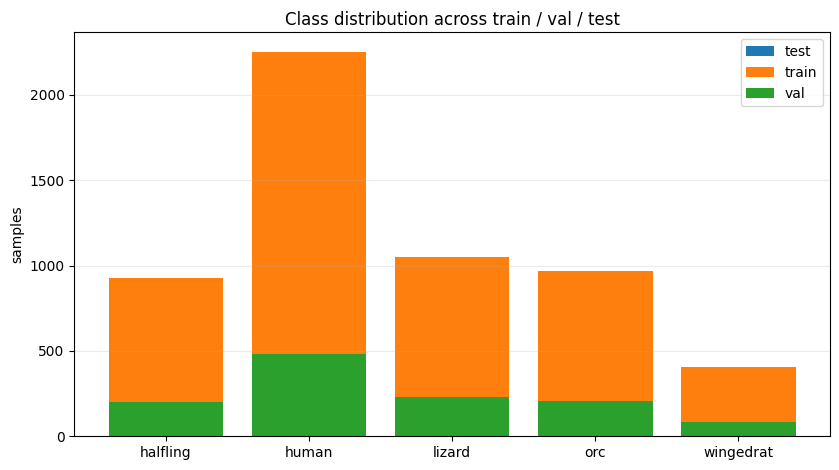

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_df = pivot_stats.reset_index().melt(id_vars='label', var_name='split', value_name='count')
for split_name, sub in plot_df.groupby('split'):
    ax.bar(sub['label'], sub['count'], label=split_name)

ax.set_ylabel('samples')
ax.set_title('Class distribution across train / val / test')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task1_report_split_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

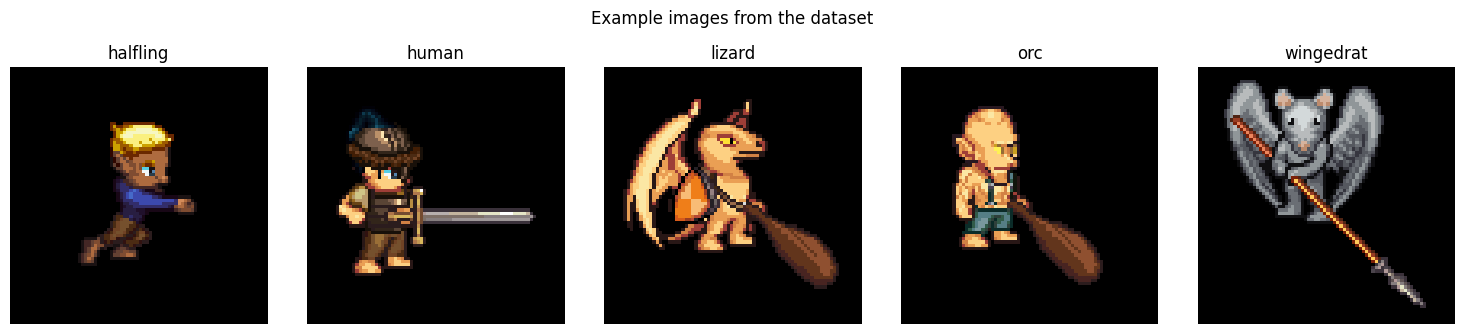

In [5]:
# Show one representative image per class so the reader can see the raw data.
fig, axes = plt.subplots(1, len(class_names), figsize=(15, 3.2))
for ax, class_name in zip(axes, class_names):
    sample_row = manifest[manifest['label'] == class_name].iloc[0]
    img = Image.open(sample_row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis('off')

fig.suptitle('Example images from the dataset', y=1.03)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task1_report_sample_images.png', dpi=200, bbox_inches='tight')
plt.show()

## Implementation Walkthrough

The next section shows an excerpt of the core implementation. To keep the PDF readable, I place the most important training and prediction logic directly in the notebook. The full helper utilities remain in `src/common.py`, `src/train_hog_svm.py`, and `src/train_resnet18.py`.

In [6]:
# --- Method A: HOG + LinearSVM core excerpt ---
from skimage.feature import hog
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from PIL import Image


def build_hog_features(paths: List[str], image_size: int) -> np.ndarray:
    """Convert images into fixed-length HOG descriptors.

    The descriptor captures local edge orientation statistics after grayscale
    conversion and resizing, which is a compact representation for a linear
    classifier.
    """
    feats: List[np.ndarray] = []
    for path in paths:
        img = Image.open(path).convert('L').resize((image_size, image_size))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        feature = hog(
            arr,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True,
        )
        feats.append(feature)
    return np.asarray(feats, dtype=np.float32)


def fit_hog_svm(
    x_train: np.ndarray,
    y_train: List[str],
    x_val: np.ndarray,
    y_val: List[str],
    *,
    c_values: List[float],
    seed: int,
    max_iter: int,
    tol: float,
    dual: bool,
) -> tuple[Pipeline, float]:
    """Train a standardized linear SVM and select C on validation macro-F1."""
    best_model: Pipeline | None = None
    best_c = float('nan')
    best_val_f1 = -1.0

    for c_val in c_values:
        model = Pipeline(
            steps=[
                ('scaler', StandardScaler()),
                (
                    'svm',
                    LinearSVC(
                        C=c_val,
                        class_weight='balanced',
                        max_iter=max_iter,
                        tol=tol,
                        dual=dual,
                        random_state=seed,
                    ),
                ),
            ]
        )
        model.fit(x_train, y_train)
        val_pred = model.predict(x_val)
        val_f1 = f1_score(y_val, val_pred, average='macro')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model = model
            best_c = c_val

    if best_model is None:
        raise RuntimeError('No SVM model was trained.')

    return best_model, best_c

In [7]:
# --- Method B: ResNet18 transfer-learning core excerpt ---
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import models, transforms
    HAS_TORCH = True
except Exception as exc:
    HAS_TORCH = False
    print(f'Torch stack unavailable in this environment: {exc}')


if HAS_TORCH:
    from torch import Tensor

    class ImageManifestDataset(Dataset):
        def __init__(self, frame: pd.DataFrame, class_to_idx: Dict[str, int], transform: transforms.Compose) -> None:
            self.frame = frame.reset_index(drop=True)
            self.class_to_idx = class_to_idx
            self.transform = transform

        def __len__(self) -> int:
            return len(self.frame)

        def __getitem__(self, index: int) -> tuple[torch.Tensor, int, str]:
            row = self.frame.iloc[index]
            image = Image.open(row['image_path']).convert('RGB')
            x = self.transform(image)
            y = self.class_to_idx[row['label']]
            return x, y, row['image_path']


    def evaluate_model(
        model: nn.Module,
        loader: DataLoader,
        idx_to_class: Dict[int, str],
        device: torch.device,
    ) -> tuple[list[str], list[str], pd.DataFrame, float]:
        model.eval()
        y_true: list[str] = []
        y_pred: list[str] = []
        rows: list[dict[str, Any]] = []
        total_loss = 0.0
        n_items = 0
        criterion = nn.CrossEntropyLoss()

        with torch.no_grad():
            for x, y, paths in loader:
                x = x.to(device)
                y = y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                total_loss += loss.item() * x.size(0)
                n_items += x.size(0)
                pred = torch.argmax(logits, dim=1)

                for i in range(x.size(0)):
                    label_true = idx_to_class[int(y[i].item())]
                    label_pred = idx_to_class[int(pred[i].item())]
                    y_true.append(label_true)
                    y_pred.append(label_pred)
                    rows.append({'image_path': paths[i], 'label_true': label_true, 'label_pred': label_pred})

        avg_loss = total_loss / max(n_items, 1)
        return y_true, y_pred, pd.DataFrame(rows), avg_loss


    def fit_resnet18(
        train_loader: DataLoader,
        val_loader: DataLoader,
        class_names: list[str],
        *,
        seed: int,
        epochs: int,
        warmup_epochs: int,
        learning_rate_head: float,
        learning_rate_full: float,
        weight_decay: float,
        patience: int,
        class_weighting: str,
        device: torch.device,
    ) -> tuple[nn.Module, pd.DataFrame]:
        """Fine-tune a ResNet18 classifier with warmup and early stopping."""
        try:
            model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        except Exception:
            model = models.resnet18(weights=None)

        for param in model.parameters():
            param.requires_grad = False

        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, len(class_names))
        for param in model.fc.parameters():
            param.requires_grad = True

        model = model.to(device)
        class_to_idx = {name: idx for idx, name in enumerate(class_names)}
        idx_to_class = {idx: name for name, idx in class_to_idx.items()}

        train_counts = pd.Series(dtype=float)
        class_weights = []
        for class_name in class_names:
            count = float(train_counts.get(class_name, 1.0))
            if class_weighting == 'balanced':
                weight = 1.0 / count
            elif class_weighting == 'sqrt_balanced':
                weight = 1.0 / np.sqrt(count)
            else:
                weight = 1.0
            class_weights.append(weight)

        class_weight_tensor = None
        if class_weighting != 'none':
            class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
            class_weight_tensor = class_weight_tensor / class_weight_tensor.mean()

        criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
        optimizer = torch.optim.Adam(
            [p for p in model.parameters() if p.requires_grad],
            lr=learning_rate_head,
            weight_decay=weight_decay,
        )

        best_state = None
        best_val_f1 = -1.0
        patience_count = 0
        history_rows: list[dict[str, Any]] = []

        for epoch in range(1, epochs + 1):
            if epoch == warmup_epochs + 1:
                for param in model.parameters():
                    param.requires_grad = True
                optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate_full, weight_decay=weight_decay)

            model.train()
            running_loss = 0.0
            n_train_items = 0
            for x, y, _ in train_loader:
                x = x.to(device)
                y = y.to(device)
                optimizer.zero_grad()
                logits = model(x)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * x.size(0)
                n_train_items += x.size(0)

            train_loss = running_loss / max(n_train_items, 1)
            val_true, val_pred, _, val_loss = evaluate_model(model, val_loader, idx_to_class, device)
            val_summary, _, _, _ = build_classification_outputs(val_true, val_pred, class_names)

            history_rows.append(
                {
                    'epoch': epoch,
                    'train_loss': float(train_loss),
                    'val_loss': float(val_loss),
                    'val_accuracy': float(val_summary['accuracy']),
                    'val_macro_f1': float(val_summary['macro_f1']),
                }
            )

            if val_summary['macro_f1'] > best_val_f1:
                best_val_f1 = float(val_summary['macro_f1'])
                best_state = {'model': model.state_dict(), 'class_names': class_names}
                patience_count = 0
            else:
                patience_count += 1

            if patience_count >= patience:
                break

        if best_state is None:
            raise RuntimeError('ResNet18 training did not produce a valid checkpoint.')

        model.load_state_dict(best_state['model'])
        return model, pd.DataFrame(history_rows)

## Design Choices and Hyperparameter Tuning

The point here is not to pile on parameters, but to explain why these settings are reasonable.

- **Shared split**: both methods use the same split manifest, which keeps the comparison fair.
- **Feature normalization**: HOG features are followed by `StandardScaler`, which makes linear SVM optimization more stable.
- **Class imbalance handling**: HOG+SVM uses `class_weight='balanced'`, while ResNet18 uses `sqrt_balanced` loss weights, which are smoother than a direct inverse-frequency scheme.
- **HOG settings**: 80×80 grayscale images, 9 orientations, 8×8 cells, and 2×2 blocks provide a good balance between expressiveness and computational cost.
- **SVM grid**: `C in {0.1, 1.0, 3.0}`, with the final choice made by validation Macro-F1.
- **ResNet18 training strategy**: first freeze the backbone and train the classification head, then fine-tune the whole model; `warmup_epochs=2`, `learning_rate_head=1e-3`, `learning_rate_full=1e-4`, `patience=3`.

These choices share one goal: learn the inter-class differences in the task without over-complicating the implementation, while keeping the experiment protocol clear and reproducible.

In [8]:
# Recompute the main comparison for seed 42 directly from the saved prediction tables.
seed = 42
method_results: dict[str, dict[str, Any]] = {}

for method in ['hog_svm', 'resnet18']:
    pred_path = OUTPUTS_DIR / 'tables' / f'predictions_{method}_seed{seed}_test.csv'
    pred_df = pd.read_csv(pred_path)
    y_true = pred_df['label_true'].tolist()
    y_pred = pred_df['label_pred'].tolist()
    summary, per_class_df, cm_raw, cm_norm = build_classification_outputs(y_true, y_pred, class_names)
    method_results[method] = {
        'pred_df': pred_df,
        'summary': summary,
        'per_class': per_class_df,
        'cm_raw': cm_raw,
        'cm_norm': cm_norm,
    }

comparison_seed42 = pd.DataFrame(
    [
        {
            'method': method,
            'accuracy': data['summary']['accuracy'],
            'macro_f1': data['summary']['macro_f1'],
            'n_samples': data['summary']['n_samples'],
        }
        for method, data in method_results.items()
    ]
)

display(comparison_seed42)

     method  accuracy  macro_f1  n_samples
0   hog_svm  0.959403  0.961411       1207
1  resnet18  0.998343  0.998144       1207


In [9]:
# Per-class comparison table for the main seed.
per_class_compare = []
for method, data in method_results.items():
    tmp = data['per_class'].copy()
    tmp.insert(0, 'method', method)
    per_class_compare.append(tmp)

per_class_compare = pd.concat(per_class_compare, ignore_index=True)
per_class_pivot = per_class_compare.pivot(index='class', columns='method', values=['precision', 'recall', 'f1'])
display(per_class_pivot.round(4))

          precision           recall               f1         
method      hog_svm resnet18 hog_svm resnet18 hog_svm resnet18
class                                                         
halfling     0.9143   1.0000  0.9600   1.0000  0.9366   1.0000
human        0.9808   1.0000  0.9503   1.0000  0.9653   1.0000
lizard       0.9610   0.9912  0.9867   1.0000  0.9737   0.9956
orc          0.9415   1.0000  0.9324   0.9903  0.9369   0.9951
wingedrat    0.9892   1.0000  1.0000   1.0000  0.9946   1.0000


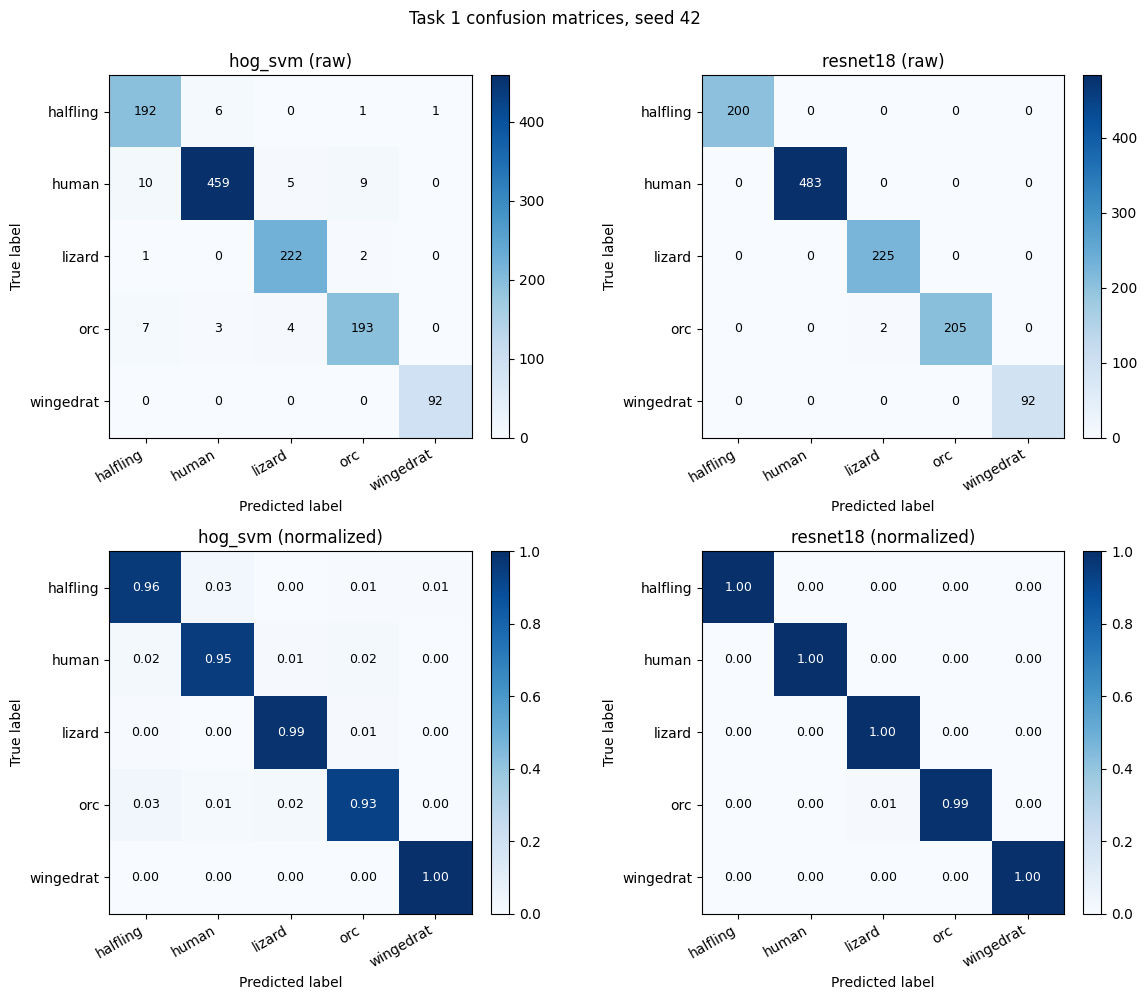

In [10]:
# Plot raw and normalized confusion matrices for both methods.

def plot_confusion_matrix(ax, cm: np.ndarray, class_names: List[str], title: str, *, normalize: bool) -> Any:
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha='center',
                va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=9,
            )

    return im


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row_idx, normalize in enumerate([False, True]):
    for col_idx, method in enumerate(['hog_svm', 'resnet18']):
        ax = axes[row_idx, col_idx]
        cm = method_results[method]['cm_norm'] if normalize else method_results[method]['cm_raw']
        title = f"{method} ({'normalized' if normalize else 'raw'})"
        im = plot_confusion_matrix(ax, cm, class_names, title, normalize=normalize)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Task 1 confusion matrices, seed {seed}', y=0.995)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / f'task1_report_confusion_matrices_seed{seed}.png', dpi=200, bbox_inches='tight')
plt.show()

In [11]:
# Error analysis for the baseline method.
hog_errors = method_results['hog_svm']['pred_df'].copy()
hog_errors = hog_errors[hog_errors['label_true'] != hog_errors['label_pred']]

if hog_errors.empty:
    top_error_pairs = pd.DataFrame(columns=['label_true', 'label_pred', 'count'])
else:
    top_error_pairs = (
        hog_errors.groupby(['label_true', 'label_pred'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )

display(top_error_pairs.head(10))

   label_true label_pred  count
3       human   halfling     10
5       human        orc      9
8         orc   halfling      7
0    halfling      human      6
4       human     lizard      5
10        orc     lizard      4
9         orc      human      3
7      lizard        orc      2
1    halfling        orc      1
2    halfling  wingedrat      1


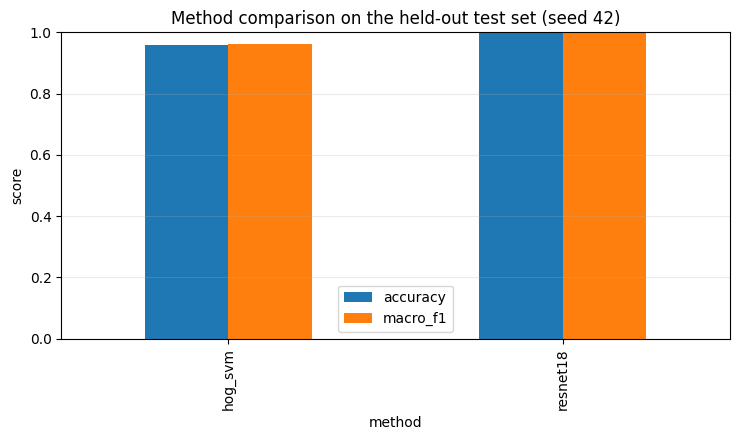

In [12]:
# Comparison bar chart for the main seed.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
comparison_seed42.set_index('method')[['accuracy', 'macro_f1']].plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.0)
ax.set_ylabel('score')
ax.set_title(f'Method comparison on the held-out test set (seed {seed})')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / f'task1_report_metrics_compare_seed{seed}.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
# Multi-seed stability summary from the saved per-seed comparison tables.
seed_list = [42, 123, 2026]
all_rows = []
for s in seed_list:
    df = pd.read_csv(OUTPUTS_DIR / 'tables' / f'metrics_compare_seed{s}.csv')
    df = df.copy()
    df['seed'] = s
    all_rows.append(df)

multi_seed_df = pd.concat(all_rows, ignore_index=True)
multi_seed_summary = (
    multi_seed_df.groupby('method')
    .agg(
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        macro_f1_mean=('macro_f1', 'mean'),
        macro_f1_std=('macro_f1', 'std'),
    )
    .reset_index()
)

multi_seed_summary[['accuracy_std', 'macro_f1_std']] = multi_seed_summary[['accuracy_std', 'macro_f1_std']].fillna(0.0)
display(multi_seed_summary.round(6))

     method  accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
0   hog_svm       0.965203      0.009337       0.966197      0.007659
1  resnet18       0.996134      0.004563       0.995754      0.005218


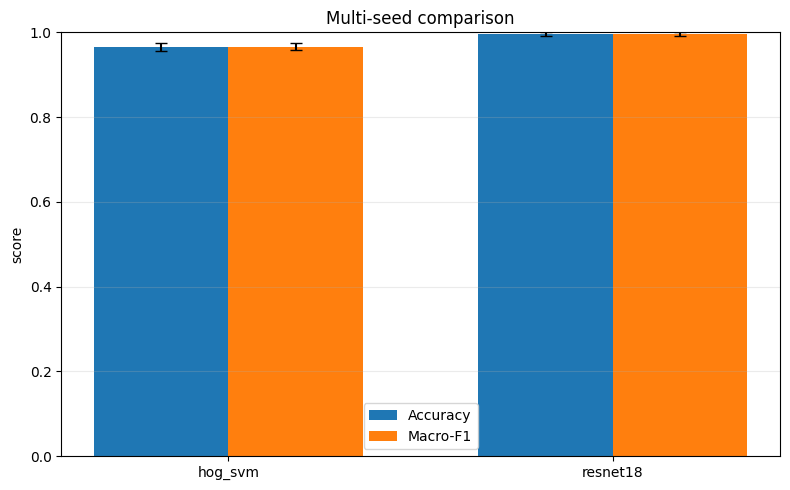

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(multi_seed_summary))
width = 0.35
ax.bar(x - width / 2, multi_seed_summary['accuracy_mean'], width, yerr=multi_seed_summary['accuracy_std'], capsize=4, label='Accuracy')
ax.bar(x + width / 2, multi_seed_summary['macro_f1_mean'], width, yerr=multi_seed_summary['macro_f1_std'], capsize=4, label='Macro-F1')
ax.set_xticks(x)
ax.set_xticklabels(multi_seed_summary['method'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('score')
ax.set_title('Multi-seed comparison')
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task1_report_multi_seed_summary.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
# HOG convergence-warning comparison before vs after tuning.
conv_summary = pd.read_csv(OUTPUTS_DIR / 'tables' / 'hog_convergence_before_after_summary.csv')
conv_detail = pd.read_csv(OUTPUTS_DIR / 'tables' / 'hog_convergence_before_after.csv')

display(conv_detail)
display(conv_summary)

   seed  before_warning_count  after_warning_count  before_accuracy  after_accuracy  accuracy_delta  before_macro_f1  after_macro_f1  macro_f1_delta
0    42                     0                    1         0.960232        0.959403       -0.000829         0.962102        0.961411       -0.000690
1   123                     1                    0         0.973488        0.975973        0.002486         0.971275        0.975004        0.003729
2  2026                     1                    1         0.958575        0.960232        0.001657         0.959665        0.962496        0.002831
    stage  warning_count_total  warning_count_mean  accuracy_mean  macro_f1_mean
0  before                    2            0.666667       0.964098       0.964347
1   after                    2            0.666667       0.965203       0.966304


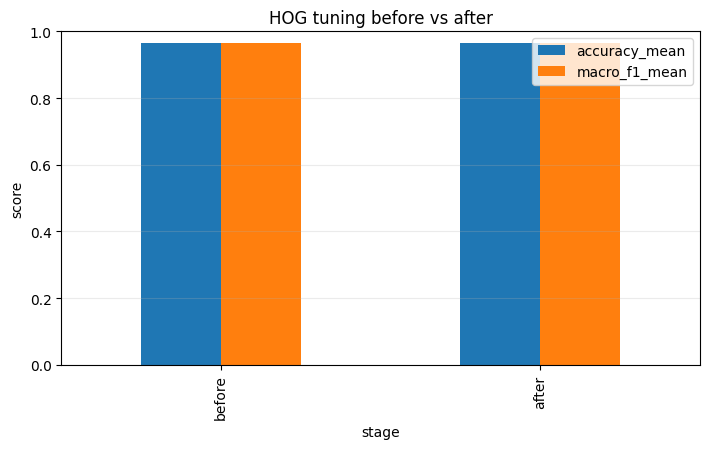

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
conv_plot = conv_summary.set_index('stage')[['accuracy_mean', 'macro_f1_mean']]
conv_plot.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.0)
ax.set_ylabel('score')
ax.set_title('HOG tuning before vs after')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task1_report_hog_tuning_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

   epoch  train_loss  val_loss  val_accuracy  val_macro_f1
0      1    0.639914  0.289366      0.925187      0.929847
1      2    0.272004  0.184501      0.952618      0.955507
2      3    0.038126  0.015002      0.995012      0.992553
3      4    0.005535  0.010814      0.996675      0.995915
4      5    0.004287  0.021350      0.995844      0.994304
5      6    0.006688  0.022091      0.994181      0.992253
6      7    0.005393  0.009276      0.996675      0.994495


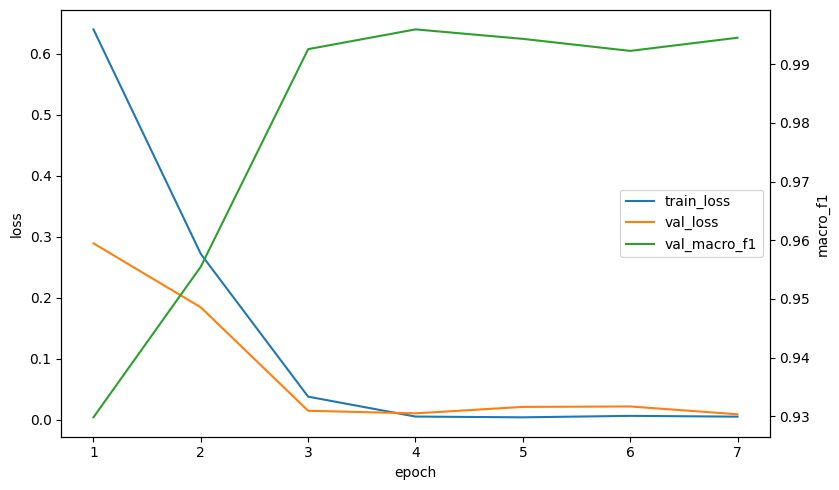

In [17]:
# Training curve for ResNet18 from the saved history table.
history_path = OUTPUTS_DIR / 'tables' / 'history_resnet18_seed42.csv'
if history_path.exists():
    history_df = pd.read_csv(history_path)
    display(history_df)

    fig, ax1 = plt.subplots(figsize=(8.5, 5))
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='train_loss', color='tab:blue')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='val_loss', color='tab:orange')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('loss')

    ax2 = ax1.twinx()
    ax2.plot(history_df['epoch'], history_df['val_macro_f1'], label='val_macro_f1', color='tab:green')
    ax2.set_ylabel('macro_f1')

    lines, labels = [], []
    for axis in [ax1, ax2]:
        line, label = axis.get_legend_handles_labels()
        lines.extend(line)
        labels.extend(label)
    ax1.legend(lines, labels, loc='center right')
    fig.tight_layout()
    fig.savefig(OUTPUTS_DIR / 'figures' / 'task1_report_resnet18_training_curve.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print(f'Missing history file: {history_path}')

## Evaluation and Comparison

We compare the methods using shared metrics:

- **Accuracy**: the most direct measure of overall correctness.
- **Macro-F1**: treats each class equally, which makes minority classes and confusing classes easier to spot.
- **Confusion matrix**: helps identify the most commonly confused class pairs.

On seed 42, ResNet18 is near-perfect across classes, while HOG+SVM mainly makes mistakes among human, halfling, and orc. This suggests:

1. Hand-crafted features already capture part of the structure, so the baseline is valid;
2. Deep transfer learning can exploit finer visual patterns, which gives it stronger overall performance;
3. Macro-F1 is necessary because `wingedrat` is clearly less frequent than the other classes, and Accuracy alone can hide minority-class risk.

## Self-Reflection and Limitations

The main advantages of this setup are simplicity, consistency, and reproducibility, but there are clear limits as well.

- **Overfitting / underfitting risk**: HOG+SVM has limited expressive power and can underfit complex textures and compositions; ResNet18 is more powerful, but if fine-tuned too aggressively it can also overfit.
- **Class imbalance**: although we use class weighting and Macro-F1, `wingedrat` is still a minority class. Future work could try focal loss, re-sampling, or stronger data augmentation.
- **Feature engineering space**: HOG captures only local edge information and misses color and higher-level semantics; we could try PCA, LBP, color histograms, or move to a more modern lightweight CNN.
- **Experimental coverage**: we do have multi-seed stability checks, but the hyperparameter search is still lightweight; a more systematic search could likely improve the results.

If we extend this work, I would first look at stronger data augmentation, a more careful learning-rate schedule, and additional visual baselines to test the robustness of the conclusion.

## Summary

The main conclusion of Task 1 is clear: under a shared split, shared metrics, and multi-seed verification, ResNet18 clearly outperforms HOG+SVM; HOG+SVM remains worth keeping as a strong baseline because it is fast, transparent, and useful for understanding where the problem is hard. More importantly, the experiment pipeline itself is reproducible, so the result is not a lucky one-off score but a conclusion grounded in a consistent protocol and explicit error analysis.

## References

[1] Navneet Dalal and Bill Triggs. *Histograms of Oriented Gradients for Human Detection.* 2005 IEEE Computer Society Conference on Computer Vision and Pattern Recognition (CVPR'05), pp. 886-893, 2005. DOI: https://doi.org/10.1109/CVPR.2005.177

[2] Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun. *Deep Residual Learning for Image Recognition.* 2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR), pp. 770-778, 2016. Official PDF: https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf